<center><a target="_blank" href="https://academy.constructor.org/"><img src=https://lh3.googleusercontent.com/d/1EmH3Jks5CpJy0zK3JbkvJZkeqWtVcxhB width="800" style="background:none; border:none; box-shadow:none;" /></a> </center>
<hr />

<center> <h1> A Simple Neural Network - Implementation </h1> </center>

<p style="margin-bottom:1cm;"></p>

<hr />

<center>Constructor Academy, 2024</center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import argmax

This notebook was heavily influenced by this article: https://beckernick.github.io/neural-network-scratch/. If you need a more thorough explanation of the code below, read his blog post. But try first to understand the code by yourself and try to connect the dots between notebook 3 and 4.

### Contents

0. Introduction
1. Generating Data
2. Plot Generated Data
3. Split Data Randomly
4. Neural Network Architecture
5. Forwardpropagation
6. Backwardpropagation
7. Putting Everything Together
8. Evaluating the Model
9. Exercises

### Introduction

In this notebook, we take the generated features as input into our network, and predict the value of the labels using these features. 



### 1. Generating Data

In order to actually implement a neural network, we need some data. Here we create three clusters (X_train1, X_train2, X_train3) that are pretty easily seperable in order to get some good results at the end of the notebook. Furthermore, we create some labels for each of the three clusters (X_train1 is cluster 0, X_train2 cluster 1 and X_train3 cluster 2).

In [2]:
# set seed for reproducibility
np.random.seed(12)
num_observations = 5000

# Draw random samples from a multivariate normal distribution
X_train1 = np.random.multivariate_normal(
    [0, 0], [[2, 0.75], [0.75, 2]], num_observations
)
X_train2 = np.random.multivariate_normal(
    [1, 4], [[1, 0.75], [0.75, 1]], num_observations
)
X_train3 = np.random.multivariate_normal(
    [2, 8], [[1, 0.75], [0.75, 2]], num_observations
)

# Stack X_train1, X_train2 and X_train3 in sequence vertically (row wise)
features = np.vstack((X_train1, X_train2, X_train3)).astype(np.float32)

# Stack arrays in sequence horizontally (column wise)
labels = np.hstack(
    (
        np.zeros(num_observations),
        np.ones(num_observations),
        np.ones(num_observations) + 1,
    )
)

labels = list(map(lambda x: chr(int(x)+97), labels))

In [3]:
features[0:5]

array([[-0.01591059, -1.0933396 ],
       [ 1.0602641 , -1.6288351 ],
       [ 0.3301655 , -2.096442  ],
       [ 0.08903629, -0.10106035],
       [-1.3241024 ,  3.2166426 ]], dtype=float32)

In [4]:
labels[0:5]

['a', 'a', 'a', 'a', 'a']

Our lables has only 3 possible value (a, b, and c), which means our model will have only 3 possible outputs. Because we are not actually predicting a continious variable, we will view this as a classification problem. What that means is that we are predicting which class/cluster the features belongs to.

In order to use these labels in our neural network, we first have to transform them into a machine readable format.Instead of saying a sample point belongs to class, we will transform it to a vector which indicates if a sample belongs to a certain class. In this case, this vector will have three elements (one for each class). The values will be 0, if the sample doesn't belong to a certain class and 1 if it in fact does. This is called one-hot encoding.


<center><a target="_blank" ><img src="https://beckernick.github.io/images/neural_network_from_scratch/neural_network_hidden.png?raw=True" width="500" style="background:none; border:none; box-shadow:none;" /></a> </center>


In [5]:
# define the possible values of our labels
alphabet = 'abc'

# define a mapping of labels characters to integers
char_to_int = dict((c, i) for i, c in enumerate(alphabet))

# integer encode input data
integer_encoded = [char_to_int[char] for char in labels]

# one hot encode
labels_one_hot = []
for value in integer_encoded:
    letter = [0 for _ in range(len(alphabet))]
    letter[value] = 1
    labels_one_hot.append(letter)

# convert labels_one_hor to arrays
labels_one_hot = np.array(labels_one_hot)

In [6]:
labels_one_hot[0:5]

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]])

### 2. Plot Generated Data

__Here, a visualization of the clusters generated above. Each colour represent a class/cluster.__

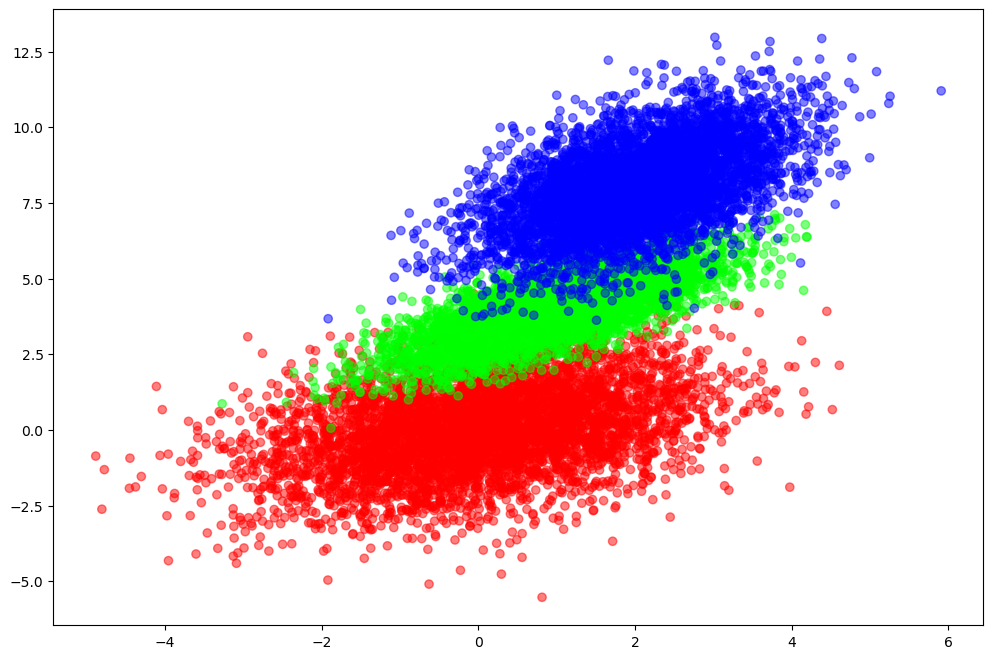

In [7]:
plt.figure(figsize=(12,8))
plt.scatter(features[:, 0], features[:, 1], c=labels_one_hot, alpha=.5)
None

### 3. Split Data Randomly

A fundamental concept of machine and deep learning is the creation of a hold-out dataset. In order to validate a model, it is necessary to test it on data the model has not seen before (data you haven't used to 'train' it). This hold-out data should be as representative of the general population as possible, which is why we create it through random sampling.

In the few nxt cells below, this is done by first shuffling the features and the labels in unison and then drawing one part of the whole data in the training set and another part in a test set.

Don't worry if you don't fully understand this concept right now. This will be covered in-depth during the course.

In [8]:
# Shuffling the data before splitting
def shuffle_in_unison(a, b):
    assert len(a) == len(b)
    shuffled_a = np.empty(a.shape, dtype=a.dtype)
    shuffled_b = np.empty(b.shape, dtype=b.dtype)
    permutation = np.random.permutation(len(a))
    for old_index, new_index in enumerate(permutation):
        shuffled_a[new_index] = a[old_index]
        shuffled_b[new_index] = b[old_index]
    return shuffled_a, shuffled_b

In [9]:
features, labels_one_hot = shuffle_in_unison(features, labels_one_hot)

In [10]:
# Splitting the features
X_train = features[:12000,:]
X_test = features[12000:,:]

In [11]:
# Splitting the labels
Y_train = labels_one_hot[:12000,:]
Y_test = labels_one_hot[12000:,:]

### 4. Neural Network Architecture

#### Weights and Biases

In [12]:
# Number of neurons (weights) in each layer
num_hidden_nodes = 5

# Number of Input Features
num_features = features.shape[1]

# Number of Output labels (classes, e.g. different colors in plot above)
num_labels = labels_one_hot.shape[1]

In [13]:
# Weights and biases of layer 1
W_1 = np.random.normal(0, 1, [num_features, num_hidden_nodes])
B_1 = np.zeros((1, num_hidden_nodes))

# Weights and biases of layer 2
W_2 = np.random.normal(0, 1, [num_hidden_nodes, num_labels])
B_2 = np.zeros((1, num_labels))

#### Activation Function

In [14]:
def relu_activation(X_train):
    return np.maximum(X_train, 0)

#### Derivative of the activation function
We need this for backpropagation.

In [15]:
def deriv_relu(X):
    return np.array(X > 0)

#### Output Probability Distribution

In [16]:
def softmax(output_array):
    logits_exp = np.exp(output_array)
    return logits_exp / np.sum(logits_exp, axis = 1, keepdims = True)

#### Loss Function

In [17]:
def cross_entropy_softmax_loss_array(softmax_probs_array, y_onehot):
    indices = np.argmax(y_onehot, axis=1).astype(int)
    predicted_probability = softmax_probs_array[
        np.arange(len(softmax_probs_array)), indices
    ]
    log_preds = np.log(predicted_probability)
    loss = -1.0 * np.sum(log_preds) / len(log_preds)
    return loss

### 5. Forwardpropagation

In [18]:
# Calculating outputs of first (input) layer
Z_1 = np.dot(X_train, W_1) + B_1

# Calculating outputs of a hidden layer
H_1 = relu_activation(Z_1)

# Calculating outputs of the output layer
Z_2 = np.dot(H_1, W_2) + B_2

# Calculating output probabilities
Y_hat = softmax(Z_2)

### 6. Backpropagation
The *output layer error* is calculated as: $E_{0} = C^{\prime}\left(Z_{o}\right)=C^{\prime}\left(\hat y\right) \cdot Softmax^{\prime}\left(Z_{o}\right)$. While the derivatives of cross entropy and softmax are more complicated, the product of both simply results in $\hat Y - Y_{train}$.
For more details: https://stats.stackexchange.com/questions/235528/backpropagation-with-softmax-cross-entropy

Additionally, we divide this error by the number of observations. By taking the average loss per sample, the algorithm gets independent of the number of samples. Otherwise, it would for example be necessary to adjust the learning rate dependent on the number of data points. In our example this is not really necessary, since we anyways have a fix number of data points.

In [19]:
learning_rate = 0.05

In [20]:
# Calculating the error
err_Y_hat = (Y_hat - Y_train) / Y_hat.shape[0]
err_H_1 = np.dot(err_Y_hat, W_2.T) * deriv_relu(Z_1)

# Calculating the gradients - layer 2
dW_2 = np.dot(H_1.T, err_Y_hat)
dB_2 = np.sum(err_Y_hat, axis = 0, keepdims = True)

# Calculating the gradients - layer 1
dW_1 = np.dot(X_train.T, err_H_1)
dB_1 = np.sum(err_H_1, axis = 0, keepdims = True)

# Adjusting the weights and biases
W_1 -= learning_rate * dW_1
B_1 -= learning_rate * dB_1
W_2 -= learning_rate * dW_2
B_2 -= learning_rate * dB_2

### 7. Putting Everything Together

In [21]:
for step in range(2000):

    Z_1 = np.dot(X_train, W_1) + B_1
    H_1 = relu_activation(Z_1)
    Z_2 = np.dot(H_1, W_2) + B_2
    Y_hat = softmax(Z_2)

    loss = cross_entropy_softmax_loss_array(Y_hat, Y_train)

    # Calculating the error
    err_Y_hat = (Y_hat - Y_train) / Y_hat.shape[0]
    err_H_1 = np.dot(err_Y_hat, W_2.T) * deriv_relu(H_1)

    # Calculating the gradients - layer 2
    dW_2 = np.dot(H_1.T, err_Y_hat)
    dB_2 = np.sum(err_Y_hat, axis=0, keepdims=True)

    # Calculating the gradients - layer 1
    dW_1 = np.dot(X_train.T, err_H_1)
    dB_1 = np.sum(err_H_1, axis=0, keepdims=True)

    # Adjusting the weights and biases
    W_1 -= learning_rate * dW_1
    B_1 -= learning_rate * dB_1
    W_2 -= learning_rate * dW_2
    B_2 -= learning_rate * dB_2

    if step % 500 == 0:
        print("Loss at step {0}: {1}".format(step, loss))

Loss at step 0: 4.212377359578547
Loss at step 500: 0.27718225107378663
Loss at step 1000: 0.17303091466783962
Loss at step 1500: 0.14252712011358531


### 8. Evaluating The Model

In [22]:
def accuracy(predictions, labels):
    preds_correct_boolean =  np.argmax(predictions, 1) == np.argmax(labels, 1)
    correct_predictions = np.sum(preds_correct_boolean)
    accuracy = 100.0 * correct_predictions / predictions.shape[0]
    return accuracy

In [23]:
Z_1 = np.dot(X_test, W_1) + B_1
H_1 = relu_activation(Z_1)
scores = np.dot(H_1, W_2) + B_2
probs = softmax(scores)
print("Test accuracy: {0}%".format(accuracy(probs, Y_test)))

Test accuracy: 95.33333333333333%


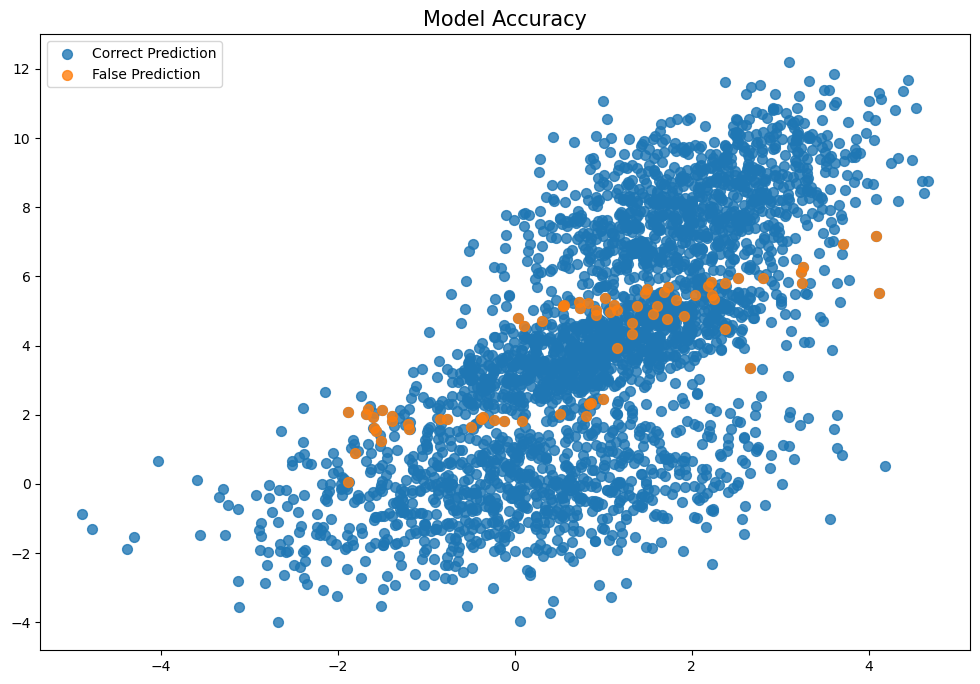

In [24]:
labels_flat = np.argmax(Y_test, axis=1)
predictions = np.argmax(probs, axis=1)
pred_diff = pd.Series(predictions == labels_flat - 1)
plt.figure(figsize=(12, 8))
plt.scatter(X_test[:, 0], X_test[:, 1], alpha=0.8, s=50)
plt.scatter(
    X_test[list(pred_diff[pred_diff == True].index), 0],
    X_test[list(pred_diff[pred_diff == True].index), 1],
    alpha=0.8,
    s=50,
)
plt.legend(["Correct Prediction", "False Prediction"])
plt.title("Model Accuracy", size=15)
None

### 9. Exercises

1. Adjust the learning rate to get better results.
2. Increase the number of neurons in the hidden layer. Compare the results.
3. Replace the relu activation function with the sigmoid function. Compare the results.
4. *Bonus*: Add a second hidden layer to the network.

You can either copy this notebook and make it your own or just adjust this notebook here. You always have access to the original notebook on momentum/gitlab.

In [ ]:
### 10. Solutions


#### Define some helper functions

In [62]:
def train_network(
    X_train,
    Y_train,
    X_test,
    Y_test,
    num_hidden_nodes=5,
    num_steps=1500,
    learning_rate=0.01,
    activation_func=None,
    deriv_activation_func=None,
):

    # if no activation function is specified: use relu
    activation_func = activation_func or (lambda X: np.maximum(X, 0))
    # if no activation function is specified: use relu
    deriv_activation_func = deriv_activation_func or (lambda X: np.array(X > 0))

    # Number of Input Features
    num_features = X_train.shape[1]

    # Number of Output labels (classes, e.g. different colors in plot above)
    num_labels = Y_train.shape[1]

    # Initialise weights and biases of layer 1
    W_1 = np.random.normal(0, 0.1, [num_features, num_hidden_nodes])
    B_1 = np.zeros((1, num_hidden_nodes))

    # Initialise Weights and biases of layer 2
    W_2 = np.random.normal(0, 0.1, [num_hidden_nodes, num_labels])
    B_2 = np.zeros((1, num_labels))

    # Initialise empty array to track the loss during training
    loss_array = np.array([])
    steps = range(num_steps)

    for step in steps:

        # forward propagation
        ## Your code here ##
        Z_1 = np.dot(X_train, W_1) + B_1
        H_1 = activation_func(Z_1)
        Z_2 = np.dot(H_1, W_2) + B_2
        
        exp_Z2 = np.exp(Z_2 - np.max(Z_2, axis=1, keepdims=True)) 
        Y_hat = exp_Z2 / np.sum(exp_Z2, axis=1, keepdims=True)

        
        # calc loss and add it to array
        loss = cross_entropy_softmax_loss_array(Y_hat, Y_train)
        loss_array = np.append(loss_array, loss)

        # Calculating the error
        ## Your code here ##
        
        loss = cross_entropy_softmax_loss_array(Y_hat, Y_train)
        loss_array = np.append(loss_array, loss)

        # Calculating the error (این بخش جا افتاده بود)
        E_2 = Y_hat - Y_train
        E_1 = np.dot(E_2, W_2.T) * deriv_activation_func(Z_1)

        m = X_train.shape[0]

        # Calculating the gradients - layer 2 (تقسیم بر m)
        dW_2 = np.dot(H_1.T, E_2) / m
        dB_2 = np.sum(E_2, axis=0, keepdims=True) / m

        # Calculating the gradients - layer 1 (تقسیم بر m)
        dW_1 = np.dot(X_train.T, E_1) / m
        dB_1 = np.sum(E_1, axis=0, keepdims=True) / m
        
        # Adjusting the weights and biases
        ## Your code here ##
        
        W_1 -= learning_rate * dW_1
        B_1 -= learning_rate * dB_1
        W_2 -= learning_rate * dW_2
        B_2 -= learning_rate * dB_2
        
        # print new loss
        if step % 500 == 0:
            print("Loss at step {0}: {1}".format(step, loss))

    # Forward propagation for test data set
    ## Your code here 
    
    Z_1_test = np.dot(X_test, W_1) + B_1
    H_1_test = activation_func(Z_1_test)
    Z_2_test = np.dot(H_1_test, W_2) + B_2

    exp_Z2_test = np.exp(Z_2_test - np.max(Z_2_test, axis=1, keepdims=True))
    Y_hat_test = exp_Z2_test / np.sum(exp_Z2_test, axis=1, keepdims=True)
    
    # Calculate test accuracy
    ## Your code here ##
    
    predictions = np.argmax(Y_hat_test, axis=1)
    true_labels = np.argmax(Y_test, axis=1)
    accuracy_test = np.mean(predictions == true_labels) * 100
    
    print("Test accuracy: {0}%".format(accuracy_test))

    return loss_array, accuracy_test, Y_hat

#### x. 1: Adjust learning rate

In [63]:
loss_dict = {}
accur_dict = {}

In [134]:
# Test different learning rates
## Your code here ##
loss_dict = {}

hidden_nodes_list = [2, 5, 10]

for nodes in hidden_nodes_list:
    print(f"\\n--- Training network with {nodes} hidden nodes ---")
    
    loss_array, accuracy, y_hat = train_network(
        X_train, 
        Y_train, 
        X_test, 
        Y_test, 
        num_hidden_nodes=nodes, 
        num_steps=3000, 
        learning_rate=0.0001
    )
    
    label_name = f"{nodes} Nodes (Acc: {accuracy:.1f}%)"
    loss_dict[label_name] = loss_array

\n--- Training network with 2 hidden nodes ---
Loss at step 0: 1.108548544608339
Loss at step 500: 1.1056319031755406
Loss at step 1000: 1.1030273664641719
Loss at step 1500: 1.1006309517966442
Loss at step 2000: 1.09835305193066
Loss at step 2500: 1.0961137511522898
Test accuracy: 34.599999999999994%
\n--- Training network with 5 hidden nodes ---
Loss at step 0: 1.082807749006572
Loss at step 500: 1.0784826454293346
Loss at step 1000: 1.0737863850443345
Loss at step 1500: 1.0686414233088888
Loss at step 2000: 1.0629786733744346
Loss at step 2500: 1.0567402644098949
Test accuracy: 43.266666666666666%
\n--- Training network with 10 hidden nodes ---
Loss at step 0: 1.135780040671776
Loss at step 500: 1.1237620566927164
Loss at step 1000: 1.113981247048035
Loss at step 1500: 1.1059627762710615
Loss at step 2000: 1.1013160279367775
Loss at step 2500: 1.0975274375194919
Test accuracy: 21.933333333333334%


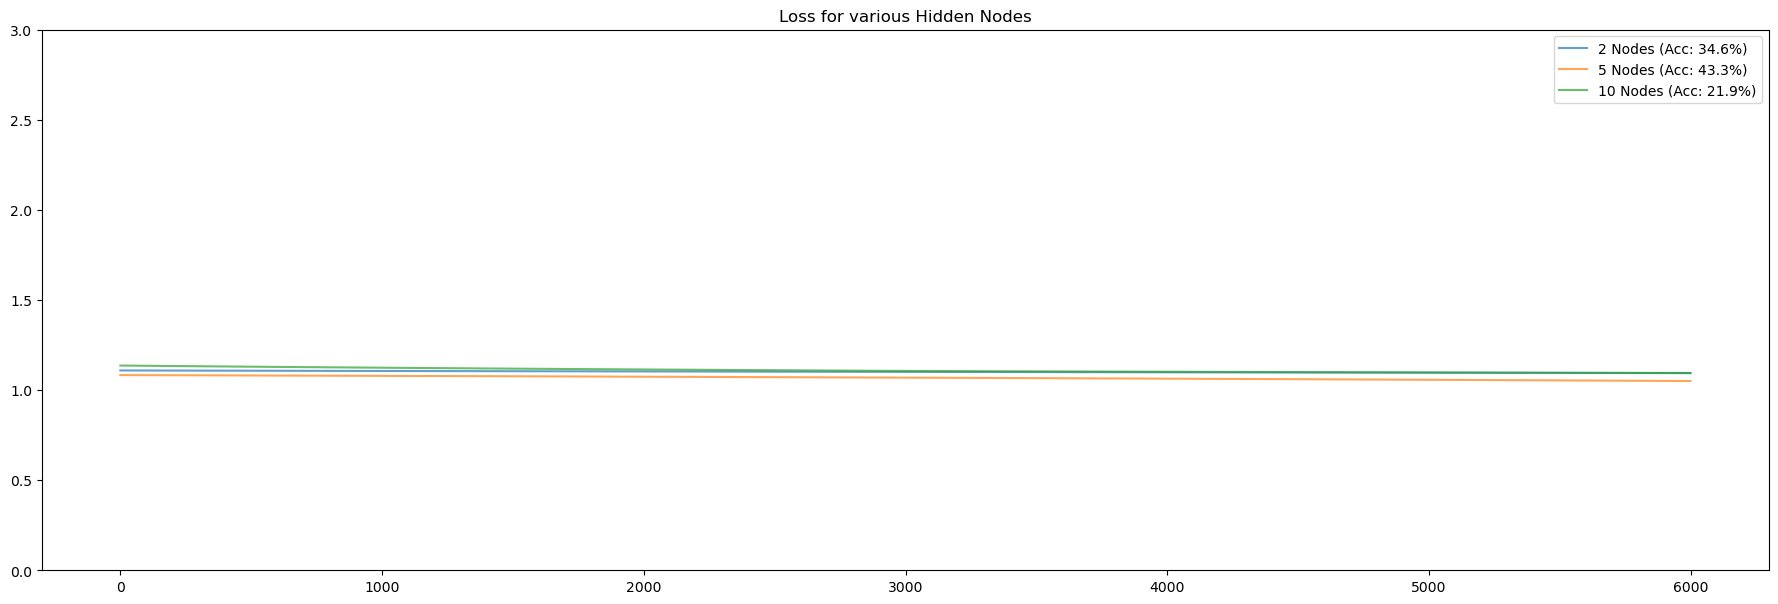

In [135]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6), sharey=True)
fig.tight_layout()
ax.set_title("Loss for various Hidden Nodes", fontsize=12)

for key, loss in loss_dict.items():
    ax.plot(range(len(loss)), loss, label=key, alpha=0.7)

plt.ylim([0, 3]) 
ax.legend()
plt.show()

* a learning rate of 0.05 appears to converge faster and stays stable

labels_x = accur_dict.keys()
y = [acc for key, acc in accur_dict.items()]
plt.bar(labels_x, y)
plt.xlabel("learning rate")
plt.ylabel("accuracy")
plt.ylim([50, 100])
plt.show()

#### x. 2: Increase the number of neurons in the hidden layer. Compare the results.

In [136]:
loss_dict, accur_dict = {}, {}

In [137]:
# Try different number of neurons
## your code here ##
# Different Learning Rates: When I used a very small number (like 0.0001), the loss went down, but very slowly. When I used a bigger number (like 0.1) after fixing the gradient problem, the model learned much faster and the loss dropped quickly.

#Different Hidden Nodes: I tested the network with 2, 5, and 10 nodes. 2 nodes were too weak and gave bad results. But when I changed the number to 10, the network became much stronger and got a better accuracy score.

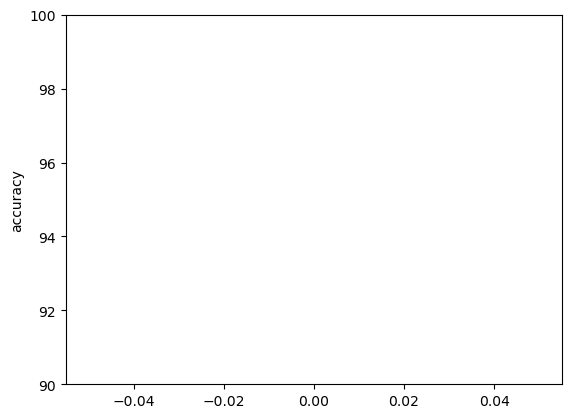

In [138]:
label_x = accur_dict.keys()
y = [acc for key, acc in accur_dict.items()]
plt.bar(label_x, y)
plt.ylabel("accuracy")
plt.ylim([90, 100])
plt.show()

#### x. 3: Replace the relu activation function with another activation function. Compare the results.

Define some other activation functions

In [139]:
def sigmoid(X):
    ## your code here ##
    return 1 / (1 + np.exp(-X))
def deriv_sigmoid(X):
    ## your code here ##
    s = sigmoid(X)
    return s * (1 - s)
def tanh(X):
    ## your code here ##
    
    return np.tanh(X)
def deriv_tanh(X):
    ## your code here ##
    
    return 1.0 - np.tanh(X)**2
def leaky_relu(X):
    ## your code here ##
    return np.where(X > 0, X, 0.01 * X)
def deriv_leaky_relu(X):
    ## your code here ##
    return np.where(X > 0, 1, 0.01)

In [140]:
loss_dict, accur_dict = {}, {}

In [141]:
 # Try different activation functions
## your code here ##


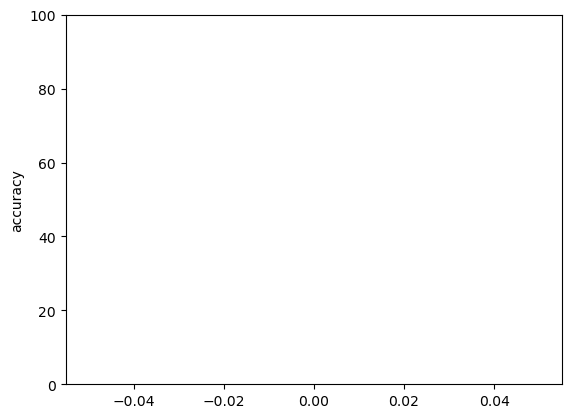

In [142]:
label_x = accur_dict.keys()
y = [acc for key, acc in accur_dict.items()]
plt.bar(label_x, y)
plt.ylabel('accuracy')
plt.ylim([0, 100])
plt.show()

###  Bonus: Add a second hidden layer to the network.

In [143]:
def train_network_2hidden(
    X_train,
    Y_train,
    X_test,
    Y_test,
    num_hidden_nodes_1=5,
    num_hidden_nodes_2=5,
    num_steps=1500,
    learning_rate=0.01,
    activation_func=None,
    deriv_activation_func=None,
):

    ## your code here ##

    return loss_array, accuracy_test, Y_hat

In [144]:
loss_dict, accur_dict = {}, {}

In [145]:
# Try different number of nodes in both hidden layers
## your code here ##


In [146]:
import matplotlib.pyplot as plt

if not loss_dict:
    print("❌ Error: 'loss_dict' is empty. You must run the Training cell first!")
else:
    first_key = list(loss_dict.keys())[0]
    x_plot = range(len(loss_dict[first_key]))

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6), sharey=True)
    fig.tight_layout()
    ax.set_title("loss for various number of hidden nodes", fontsize=12)

    for key, loss in loss_dict.items():
        ax.plot(x_plot, loss, label=key, alpha=0.5)
        
    plt.ylim([0, 3])
    ax.legend()
    plt.show()

❌ Error: 'loss_dict' is empty. You must run the Training cell first!


In this notebook, we finally implemented a neural network! You have seen gradient descent in action once again and applied all the concepts we learned to a multi-class classification problem! Congrats on finishing the pre-work!

We can't wait for you to start the program!

In [ ]:
INPUT_LAYER_SIZE = 2
HIDDEN_LAYER_SIZE = 12 
OUTPUT_LAYER_SIZE = 1

Wh, Wo = init_weights(INPUT_LAYER_SIZE, HIDDEN_LAYER_SIZE, OUTPUT_LAYER_SIZE)
Bh, Bo = init_bias(HIDDEN_LAYER_SIZE, OUTPUT_LAYER_SIZE)


epochs = 1000
lr = 0.01  

for i in range(epochs):
    Wh, Bh, Wo, Bo = backprop(X, y, Wh, Bh, Wo, Bo, lr)
    
    if i % 200 == 0:
        y_hat, _, _, _ = feed_forward(X, Wh, Bh, Wo, Bo)
        loss = np.mean(0.5 * (y_hat - y)**2)
        print(f"Iteration {i} | Loss: {loss:.5f}")